In [1]:
import pandas as pd
import torch
from pathlib import Path
from accelerate import Accelerator
from model.data_loader import ScanDataLoader
from model.model import AneurysmDetectionModel
from torchsummary import summary
from model.training_pipeline import TrainingPipeline
import torch.nn as nn
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [2]:
DATA_DIR = Path("ct_preprocessed/series")
CSV_PATH = Path("ct_preprocessed/train.csv")
INPUT_SHAPE = (256, 256, 256)
BATCH_SIZE = 1
GRADIENT_ACCUMULATION = 4# simmulate: batch_size = batch_size * gradient_accumulation
EPOCHS = 20
LEARNING_RATE = 0.0001
TRAIN_RATIO = 0.7
LEARNING_RATE_REDUCTION_EPOCHS = 4
CACHE_SIZE = 32

device = "cuda"

accelerator = Accelerator(
        mixed_precision = "fp16", 
        gradient_accumulation_steps = GRADIENT_ACCUMULATION,
    )

print("\n[1/5] Loading dataset...")
data_loader = ScanDataLoader(DATA_DIR, CSV_PATH)
x_train, y_train, x_val, y_val = data_loader.split_data(train_ratio=TRAIN_RATIO)

print("\n[2/5] Loading model...")
model = AneurysmDetectionModel()
model.load_state_dict(torch.load("aneurysm_detection_best.pt", weights_only=True))
print(type(model))
if torch.cuda.is_available():
    model = model.to(device)
    print(summary(model, input_size = (1,256,256,256)))

print("\n[3/5] Creating dataloaders...")
pipeline = TrainingPipeline(
        model=model,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        learning_rate=LEARNING_RATE,
        lr_reduction_patience = LEARNING_RATE_REDUCTION_EPOCHS,
        cache_size=CACHE_SIZE,
        grad_accum_steps=GRADIENT_ACCUMULATION
    )

train_dataloader, val_dataloader = pipeline.create_dataloaders(
    x_train, y_train, x_val, y_val
)

criterion = nn.BCEWithLogitsLoss()
print("\n[4/5] Evaluating training set...")
all_preds, all_labels = [], []
for x_batch, y_batch in tqdm(train_dataloader):
    # y to float column vector
    y_batch = y_batch.float().unsqueeze(1)

    x_batch = x_batch.to(device, dtype=torch.float32, non_blocking=True)
    y_batch = y_batch.to(device, dtype=torch.float32, non_blocking=True)

    with accelerator.autocast():
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)

    # gather predictions/labels only for metrics
    all_preds.append(outputs.detach())
    all_labels.append(y_batch.detach())

all_preds = torch.cat(all_preds, dim=0).to(device, dtype=torch.float32).contiguous()
all_labels = torch.cat(all_labels, dim=0).to(device, dtype=torch.float32).contiguous()


[1/5] Loading dataset...
Loaded 1611 scans: 897 positive, 714 negative

Dataset split:
  Training: 1126 samples (pos: 627, neg: 499)
  Validation: 485 samples (pos: 270, neg: 215)

[2/5] Loading model...
<class 'model.model.AneurysmDetectionModel'>


`log_with=[<LoggerType.TENSORBOARD: 'tensorboard'>]` was passed but no supported trackers are currently installed.


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv3d-1     [-1, 8, 256, 256, 256]             224
         MaxPool3d-2     [-1, 8, 128, 128, 128]               0
       BatchNorm3d-3     [-1, 8, 128, 128, 128]              16
            Conv3d-4    [-1, 16, 128, 128, 128]           3,472
         MaxPool3d-5       [-1, 16, 64, 64, 64]               0
       BatchNorm3d-6       [-1, 16, 64, 64, 64]              32
            Conv3d-7       [-1, 32, 64, 64, 64]          13,856
         MaxPool3d-8       [-1, 32, 32, 32, 32]               0
       BatchNorm3d-9       [-1, 32, 32, 32, 32]              64
           Conv3d-10       [-1, 64, 32, 32, 32]          55,360
        MaxPool3d-11       [-1, 64, 16, 16, 16]               0
      BatchNorm3d-12       [-1, 64, 16, 16, 16]             128
           Conv3d-13      [-1, 128, 16, 16, 16]         221,312
        MaxPool3d-14         [-1, 128, 

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1126/1126 [01:56<00:00,  9.69it/s]


In [3]:
def safe_gather(tensor, device, accelerator):
    """Safely gather tensors across processes for Gloo backend."""
    tensor = tensor.flatten().contiguous()

    # Get max size across processes
    local_size = torch.tensor(tensor.shape[0], device=device)
    all_sizes = accelerator.gather(local_size)
    max_size = all_sizes.max().item()

    # Pad to max size
    current_size = tensor.shape[0]
    if current_size == max_size:
        return accelerator.gather(tensor)

    tensor = torch.nn.functional.pad(tensor, (0, max_size - current_size), value=0)

    return accelerator.gather(tensor)


Text(0.5, 1.0, 'Training Confusion Matrix')

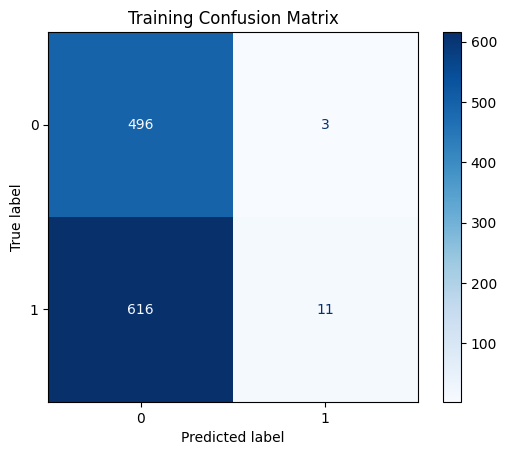

In [4]:
# Now safe to gather on GPU
all_preds  = safe_gather(all_preds, device, accelerator)
all_labels = safe_gather(all_labels, device, accelerator)

probs = torch.sigmoid(all_preds)
preds = (probs >= 0.5).int().cpu().numpy()
labs  = all_labels.int().cpu().numpy()

train_acc = accuracy_score(labs, preds)
train_conf_mat = confusion_matrix(labs, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=train_conf_mat,)
disp.plot(cmap='Blues')  # optional: add color map
plt.title("Training Confusion Matrix")

In [13]:
accelerator.backward(loss)

In [19]:
def get_layer_data(model):
  gradients = []
  layer_names = []

  with torch.no_grad():
    for name, param in model.named_parameters():
      if param.requires_grad and name.endswith('.weight') and not name.startswith('bn'):
          layer_names.append(name)
          gradients.append(param.grad)

  activations = model.layer_activations

  return layer_names, activations, gradients

layer_names, activations, gradients = get_layer_data(model)
print('layer_names',layer_names)
print('Activation list length:',len(activations))
print('Activations shape layer 1:',activations[0].shape)
print('Activations shape layer 2:',activations[1].shape)
print('Activations shape layer 3:',activations[2].shape)
print('Activations shape layer 4:',activations[3].shape)
print('Activations shape layer 5:',activations[4].shape)
print('Activations shape layer 6:',activations[5].shape)
print('Activations shape layer 7:',activations[6].shape)
print('Gradient list length:',len(gradients))
print('Gradient shape layer 1:',gradients[0].shape)
print('Gradient shape layer 2:',gradients[1].shape)
print('Gradient shape layer 3:',gradients[2].shape)
print('Gradient shape layer 4:',gradients[3].shape)
print('Gradient shape layer 5:',gradients[4].shape)
print('Gradient shape layer 6:',gradients[5].shape)
print('Gradient shape layer 7:',gradients[6].shape)

layer_names ['conv1.weight', 'conv2.weight', 'conv3.weight', 'conv4.weight', 'conv5.weight', 'fc1.weight', 'fc2.weight']
Activation list length: 7
Activations shape layer 1: torch.Size([1, 8, 368, 240, 240])
Activations shape layer 2: torch.Size([1, 16, 184, 120, 120])
Activations shape layer 3: torch.Size([1, 32, 92, 60, 60])
Activations shape layer 4: torch.Size([1, 64, 46, 30, 30])
Activations shape layer 5: torch.Size([1, 128, 23, 15, 15])
Activations shape layer 6: torch.Size([1, 256])
Activations shape layer 7: torch.Size([1, 1])
Gradient list length: 7
Gradient shape layer 1: torch.Size([8, 1, 3, 3, 3])
Gradient shape layer 2: torch.Size([16, 8, 3, 3, 3])
Gradient shape layer 3: torch.Size([32, 16, 3, 3, 3])
Gradient shape layer 4: torch.Size([64, 32, 3, 3, 3])
Gradient shape layer 5: torch.Size([128, 64, 3, 3, 3])
Gradient shape layer 6: torch.Size([256, 128])
Gradient shape layer 7: torch.Size([1, 256])


In [21]:
def get_layer_stats(x,absolute=False):
  avg = []
  std = []
  for layer in range(len(x)):
    if absolute:
      avg.append(x[layer].abs().mean().detach().cpu().numpy())
    else:
      avg.append(x[layer].mean().detach().cpu().numpy())

    std.append(x[layer].std().detach().cpu().numpy())

  return avg, std

activation_mean, activation_std = get_layer_stats(activations)
gradient_mean, gradient_std = get_layer_stats(gradients,absolute=True)

print('activation_mean',activation_mean)
print('activation_std',activation_std)
print('gradient_mean',gradient_mean)
print('gradient_std',gradient_std)

activation_mean [array(0.02402, dtype=float16), array(0.2041, dtype=float16), array(0.2196, dtype=float16), array(0.2627, dtype=float16), array(0.3477, dtype=float16), array(0.02614, dtype=float16), array(-0.0512, dtype=float16)]
activation_std [array(0.05884, dtype=float16), array(0.4028, dtype=float16), array(0.375, dtype=float16), array(0.4126, dtype=float16), array(0.516, dtype=float16), array(0.0297, dtype=float16), array(nan, dtype=float16)]
gradient_mean [array(0., dtype=float32), array(0., dtype=float32), array(0., dtype=float32), array(4.360681e-07, dtype=float32), array(4.045639e-06, dtype=float32), array(0.35782582, dtype=float32), array(220.156, dtype=float32)]
gradient_std [array(0., dtype=float32), array(0., dtype=float32), array(0., dtype=float32), array(7.910609e-07, dtype=float32), array(6.8947347e-06, dtype=float32), array(0.765472, dtype=float32), array(329.49777, dtype=float32)]


std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)


Gradients:



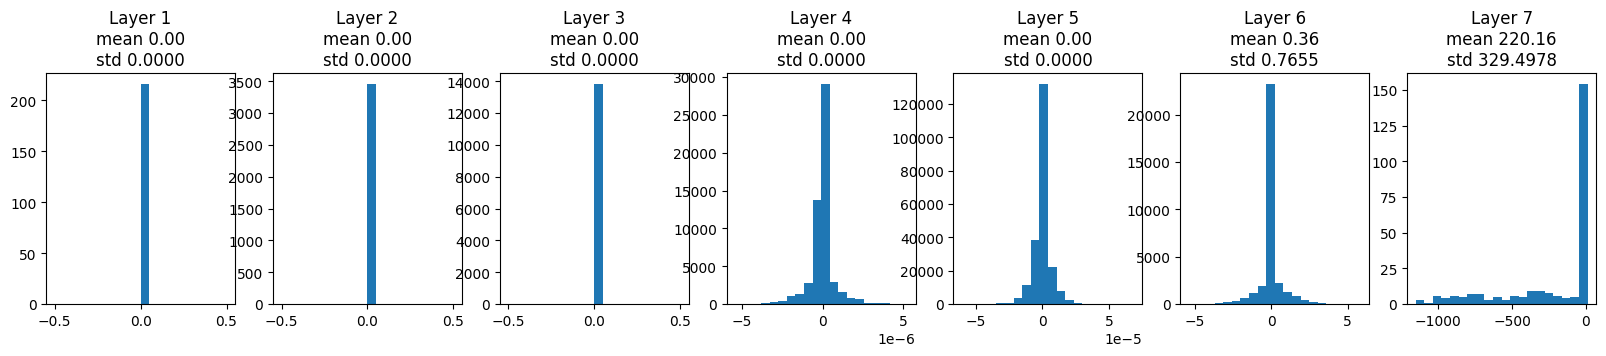

Activations:



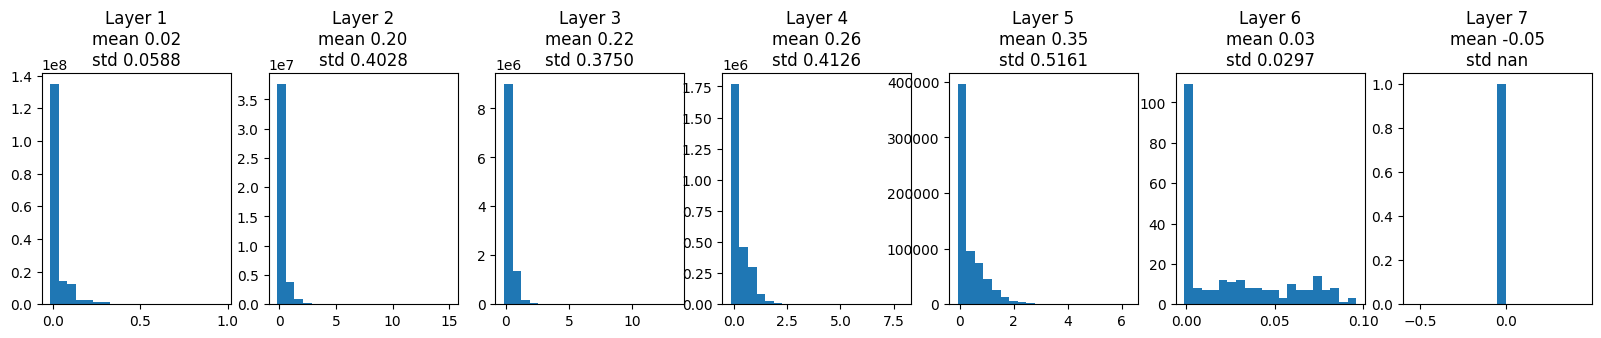

In [22]:
def plot_hist(hs,xrange=(-1,1),avg=None,sd=None):
  plt.figure(figsize=(20,3))
  for layer in range(len(hs)):
    plt.subplot(1,len(hs),layer+1)
    activations = hs[layer].detach().cpu().numpy().flatten()
    plt.hist(activations, bins=20, range=xrange)

    title = 'Layer ' + str(layer+1)
    if avg:
      title += '\n' + "mean {0:.2f}".format(avg[layer])
    if sd:
      title += '\n' + "std {0:.4f}".format(sd[layer])

    plt.title(title)

print('Gradients:\n')
plot_hist(gradients,xrange=None,avg=gradient_mean,sd=gradient_std)
plt.show()

print('Activations:\n')
plot_hist(activations,xrange=None,avg=activation_mean,sd=activation_std)
plt.show()
